# 🧱 MEDALLION ARCHITECTURE — GROUP BY MASTERCLASS

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()

In [2]:
INPUT_PATH = "/Users/max/mp/github/data-warehousing/syllabus/week01-Foundations-SQL-for-Analytics/group_by_examples"
file_path = f"/Users/max/mp/github/data-warehousing/syllabus/week01-Foundations-SQL-for-Analytics/group_by_examples/sales.csv"

## 🥉 Bronze Layer

In [5]:
con.execute(f"""
CREATE OR REPLACE TABLE bronze_sales AS
SELECT * FROM read_csv_auto('{file_path}');
""")

In [6]:
con.execute(f"""
SELECT * FROM  bronze_sales LIMIT 5;
""").df()

,transaction_id,transaction_date,product_name,price,quantity,discount,gender,country,age,sales_amount
0,1,2024-02-15,LAPTOP,1500,1,0.02,FEMALE,FRANCE,56,1470.0
1,2,2025-11-07,BIKE,500,1,0.02,FEMALE,USA,37,588.0
2,3,2025-03-12,TV,800,2,0.19,FEMALE,MEXICO,65,1296.0
3,4,2024-10-17,LAPTOP,1500,1,0.03,MALE,CHINA,29,1455.0
4,5,2023-06-20,IPAD,900,1,0.07,FEMALE,CANADA,66,920.7


## 🥈 Silver Layer

In [8]:
con.execute(f"""
CREATE OR REPLACE TABLE silver_sales AS
SELECT *,
    EXTRACT(YEAR FROM transaction_date) AS year,
    EXTRACT(MONTH FROM transaction_date) AS month,
    EXTRACT(QUARTER FROM transaction_date) AS quarter,
    STRFTIME(transaction_date, '%A') AS day_of_week,
    price * quantity * (1 - discount) AS sale_price
FROM bronze_sales;
""")

In [9]:
con.execute(f"""
SELECT * FROM  silver_sales LIMIT 5;
""").df()

,transaction_id,transaction_date,product_name,price,quantity,discount,gender,country,age,sales_amount,year,month,quarter,day_of_week,sale_price
0,1,2024-02-15,LAPTOP,1500,1,0.02,FEMALE,FRANCE,56,1470.0,2024,2,1,Thursday,1470.0
1,2,2025-11-07,BIKE,500,1,0.02,FEMALE,USA,37,588.0,2025,11,4,Friday,490.0
2,3,2025-03-12,TV,800,2,0.19,FEMALE,MEXICO,65,1296.0,2025,3,1,Wednesday,1296.0
3,4,2024-10-17,LAPTOP,1500,1,0.03,MALE,CHINA,29,1455.0,2024,10,4,Thursday,1455.0
4,5,2023-06-20,IPAD,900,1,0.07,FEMALE,CANADA,66,920.7,2023,6,2,Tuesday,837.0


## 📊 Monthly Revenue
**Insight Goal:** Trend over time

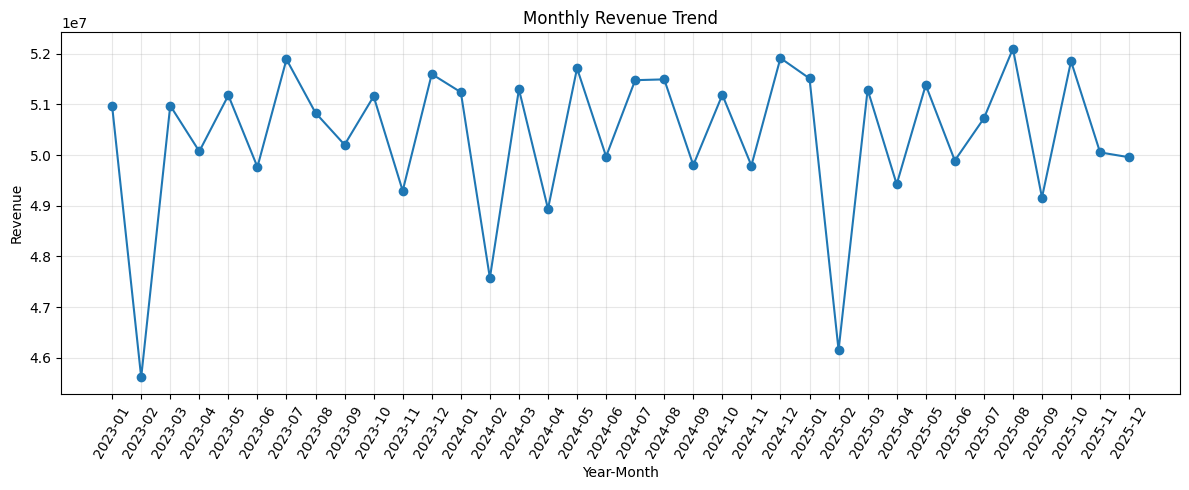

In [11]:
df = con.execute("""
SELECT year, month, SUM(sale_price) AS revenue
FROM silver_sales
GROUP BY year, month
ORDER BY year, month
""").df()

# Create proper time label
df["year_month"] = df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.plot(df["year_month"], df["revenue"], marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=60)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Quarterly Revenue
**Insight Goal:** Seasonality

/var/folders/_5/wx3bhmf91dq3fv1bjwmpdlzc0000gn/T/ipykernel_57274/46655067.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


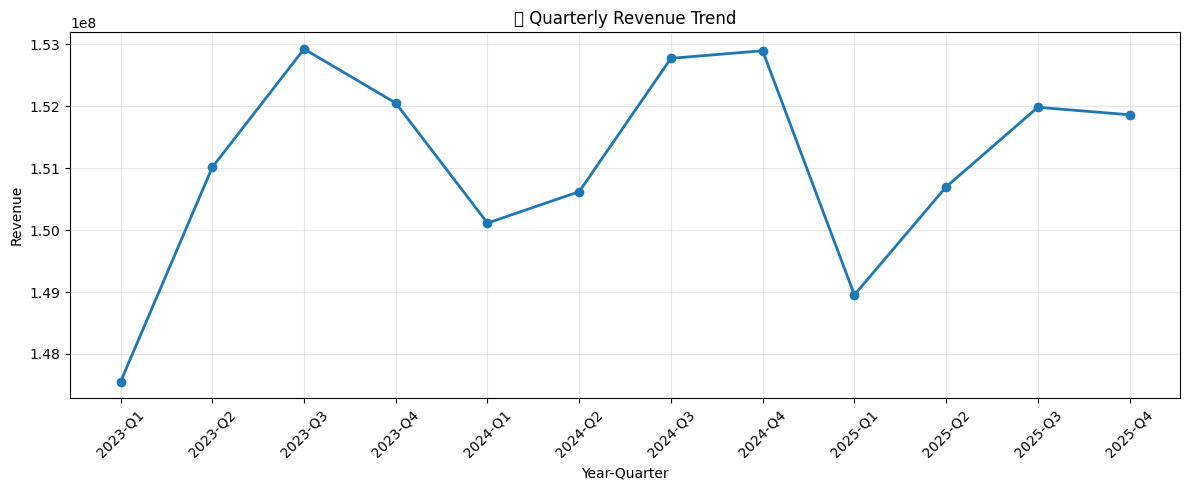

In [13]:
df = con.execute("""
SELECT year, quarter, SUM(sale_price) AS revenue
FROM silver_sales
GROUP BY year, quarter
ORDER BY year, quarter
""").df()

# Create proper label: 2023-Q1, etc.
df["year_quarter"] = df["year"].astype(str) + "-Q" + df["quarter"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(df["year_quarter"], df["revenue"], marker='o', linewidth=2)

plt.title("📊 Quarterly Revenue Trend")
plt.xlabel("Year-Quarter")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Revenue by Country
**Insight Goal:** Market performance

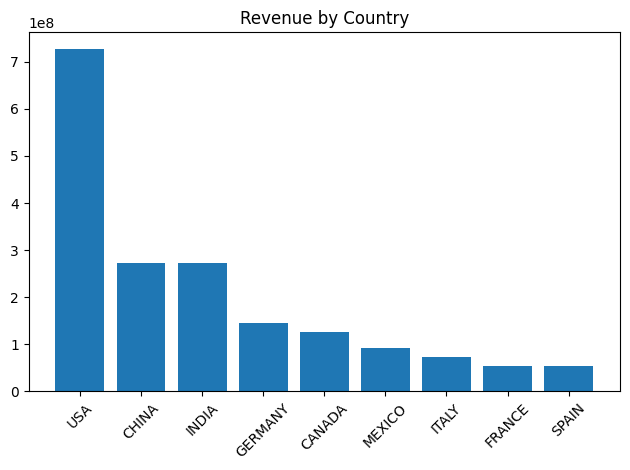

In [14]:
df = con.execute("""SELECT country, SUM(sale_price) AS revenue
FROM silver_sales
GROUP BY country
ORDER BY revenue DESC""").df()

plt.figure()
plt.bar(df[df.columns[0]], df[df.columns[1]])
plt.xticks(rotation=45)
plt.title("Revenue by Country")
plt.tight_layout()
plt.show()

## 📊 Revenue by Product
**Insight Goal:** Product strategy

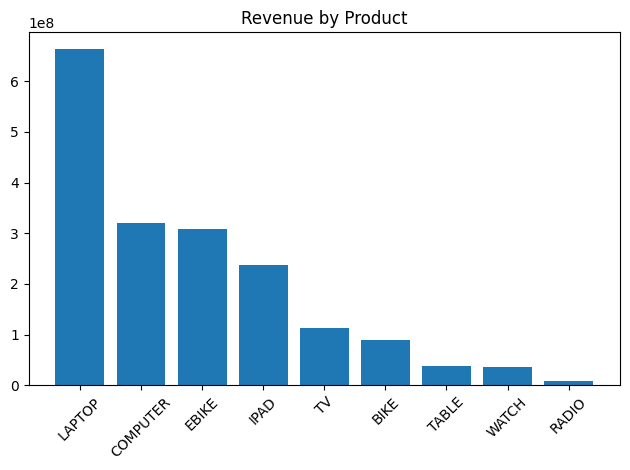

In [15]:
df = con.execute("""SELECT product_name, SUM(sale_price) AS revenue
FROM silver_sales
GROUP BY product_name
ORDER BY revenue DESC""").df()

plt.figure()
plt.bar(df[df.columns[0]], df[df.columns[1]])
plt.xticks(rotation=45)
plt.title("Revenue by Product")
plt.tight_layout()
plt.show()

## 📊 Revenue by Day of Week
**Insight Goal:** Weekend vs weekday

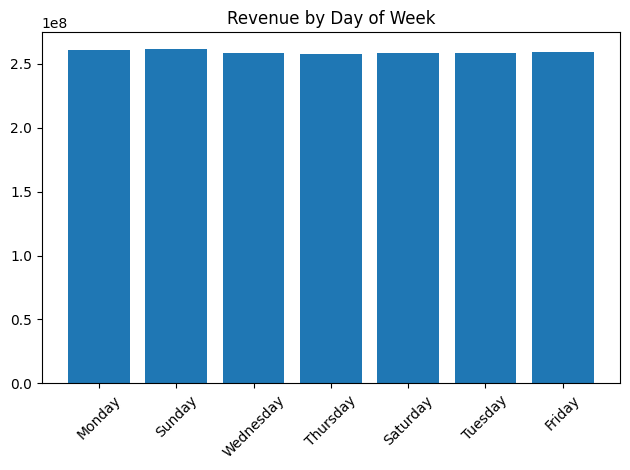

In [16]:
df = con.execute("""SELECT day_of_week, SUM(sale_price) AS revenue
FROM silver_sales
GROUP BY day_of_week""").df()

plt.figure()
plt.bar(df[df.columns[0]], df[df.columns[1]])
plt.xticks(rotation=45)
plt.title("Revenue by Day of Week")
plt.tight_layout()
plt.show()

## 🥇 Gold Layer

In [19]:
# 🟨 🧱 Cell 1 — SQL (Gold Layer)
df = con.execute("""
SELECT 
    year,
    quarter,
    SUM(sale_price) AS total_revenue,
    COUNT(*) AS total_orders,
    AVG(sale_price) AS avg_order_value
FROM silver_sales
GROUP BY year, quarter
ORDER BY year, quarter
""").df()

df.head(20)

,year,quarter,total_revenue,total_orders,avg_order_value
0,2023,1,147552782.5,81837,1803.008205
1,2023,2,151014587.0,82791,1824.045935
2,2023,3,152923681.0,84384,1812.235507
3,2023,4,152050802.5,84006,1809.999316
4,2024,1,150113265.5,82975,1809.138481
5,2024,2,150620470.5,83046,1813.699281
6,2024,3,152772584.0,84016,1818.374881
7,2024,4,152894999.0,84240,1814.992866
8,2025,1,148953485.5,82380,1808.126797
9,2025,2,150697050.0,83168,1811.959528


```
Business Insight:

1. Quarterly revenue helps identify seasonality patterns.
2. Compare Q1–Q4 performance across years to detect growth trends.
3. Total orders vs revenue:
   - High revenue + low orders → high-value purchases
   - High orders + lower revenue → volume-driven sales
4. Average order value indicates pricing strength and customer spending behavior.

Key Questions:
- Which quarter performs best?
- Is there consistent growth year over year?
- Are we improving revenue per transaction?
```

/var/folders/_5/wx3bhmf91dq3fv1bjwmpdlzc0000gn/T/ipykernel_57274/1090217572.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


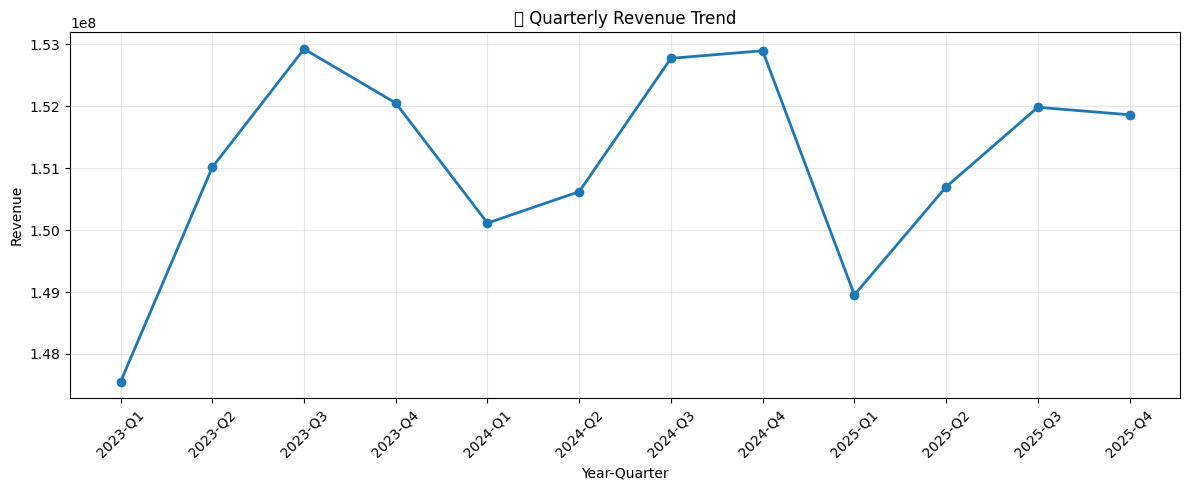

In [20]:
# 📊 🟨 Cell 3 — Plot (Executive Quality)

import matplotlib.pyplot as plt

# Create label
df["year_quarter"] = df["year"].astype(str) + "-Q" + df["quarter"].astype(str)

plt.figure(figsize=(12, 5))

plt.plot(df["year_quarter"], df["total_revenue"], marker='o', linewidth=2)

plt.title("📊 Quarterly Revenue Trend")
plt.xlabel("Year-Quarter")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

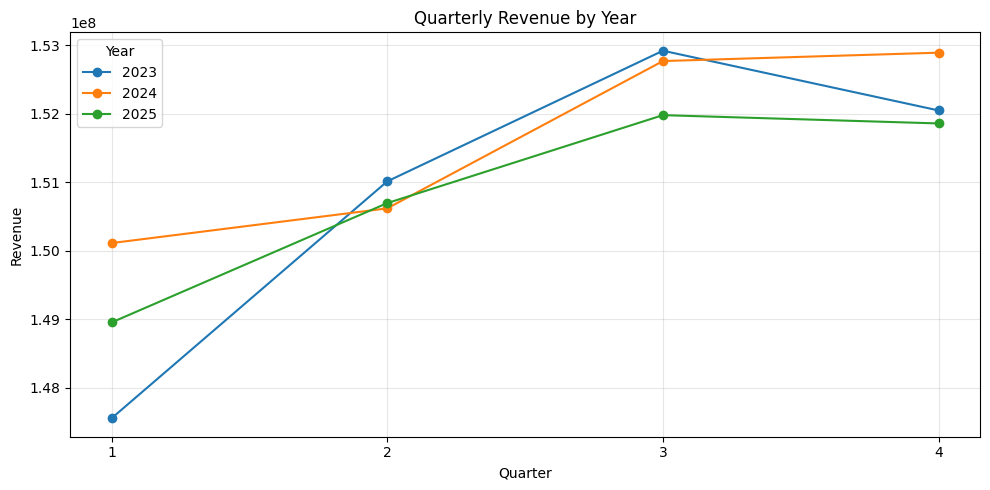

In [21]:
# 👉 Add comparison across years

plt.figure(figsize=(10, 5))

for year in sorted(df["year"].unique()):
    temp = df[df["year"] == year]
    plt.plot(temp["quarter"], temp["total_revenue"], marker='o', label=year)

plt.title("Quarterly Revenue by Year")
plt.xlabel("Quarter")
plt.ylabel("Revenue")

plt.xticks([1,2,3,4])
plt.legend(title="Year")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()